# MedSAM — Experimento Final: Último bloque del encoder descongelado
Fine-tuning con el último bloque del image encoder descongelado.

In [1]:
import os, json, random
from pathlib import Path
from dotenv import load_dotenv

# Carga .env desde la carpeta del notebook (funciona en Jupyter y scripts)
_env_path = Path(globals().get("__file__", ".")).parent / ".env"
load_dotenv(_env_path)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED)
print('✅ Entorno listo')


✅ Entorno listo


In [ ]:
# ==========================================
# PARTE 1: IMPORTS + CONFIG + SPLITS
# ==========================================

%matplotlib inline
import os
import random
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

from segment_anything import sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide

# -----------------------------
# Configuración general
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# -----------------------------
# Rutas principales
# -----------------------------
PROJECT_ROOT = Path(r"/Users/anferiro/personal/maia/proyecto/Segmentacion_semantica_columna/medsam")
MEDSAM_CKPT_PATH = Path(r"/Users/anferiro/personal/maia/proyecto/Segmentacion_semantica_columna/medsam/models/sam_vit_b_01ec64.pth")
SAVE_DIR = PROJECT_ROOT / "medsam_checkpoints"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("Checkpoint exists:", MEDSAM_CKPT_PATH.exists())
if not MEDSAM_CKPT_PATH.exists():
    raise FileNotFoundError(f"No existe el checkpoint: {MEDSAM_CKPT_PATH}")

# -----------------------------
# Buscar splits.csv
# -----------------------------
possible_splits = list(PROJECT_ROOT.rglob("splits.csv"))
print("splits.csv encontrados:")
for p in possible_splits:
    print(" -", p)

# Si ves la ruta correcta en la salida anterior, déjala aquí:
SPLITS_CSV = possible_splits[0]  # ajusta esto si aparecen varios

if not SPLITS_CSV.exists():
    raise FileNotFoundError(f"No existe splits.csv en: {SPLITS_CSV}")

print("Usando splits.csv:", SPLITS_CSV)

# -----------------------------
# Leer splits
# -----------------------------
df_splits = pd.read_csv(SPLITS_CSV)

print("Columnas disponibles:")
print(df_splits.columns.tolist())

print("\nConteo por split:")
print(df_splits["split"].value_counts(dropna=False))

# Separación ya definida previamente
df_train = df_splits[df_splits["split"] == "train"].copy()
df_val   = df_splits[df_splits["split"] == "val"].copy()
df_test  = df_splits[df_splits["split"] == "test"].copy()

print("\nTamaños:")
print("Train:", len(df_train))
print("Val  :", len(df_val))
print("Test :", len(df_test))


/Users/anferiro/Library/Mobile Documents/com~apple~CloudDocs/personal/maia/proyecto/columna/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
Checkpoint exists: True
splits.csv encontrados:
 - /Users/anferiro/personal/maia/proyecto/columna/recursos/dataset_procesado/splits.csv
Usando splits.csv: /Users/anferiro/personal/maia/proyecto/columna/recursos/dataset_procesado/splits.csv
Columnas disponibles:
['patient_id', 'tipo', 'split', 'ruta_img', 'ruta_mask_id']

Conteo por split:
split
train    174
test      38
val       37
Name: count, dtype: int64

Tamaños:
Train: 174
Val  : 37
Test : 38


In [3]:
# ==========================================
# MLflow - CONFIGURACIÓN DESDE ENV VARS
# ==========================================
import os
import mlflow
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path(".") / ".env")  # Lee DATABRICKS_HOST y DATABRICKS_TOKEN desde tareas/week4/.env

# Variables de ambiente requeridas:
#   DATABRICKS_HOST  → URL del workspace (ej: https://xxx.azuredatabricks.net)
#   DATABRICKS_TOKEN → Personal Access Token de Databricks
#   MLFLOW_EXPERIMENT_NAME → Nombre del experimento (opcional)

DATABRICKS_HOST  = os.getenv("DATABRICKS_HOST", "")
DATABRICKS_TOKEN = os.getenv("DATABRICKS_TOKEN", "")
MLFLOW_EXP_NAME  = os.getenv("MLFLOW_EXPERIMENT_NAME", "columna-vertebral-medsam")

print(DATABRICKS_HOST)

if not DATABRICKS_HOST:
    raise EnvironmentError("❌ DATABRICKS_HOST no está definida como variable de ambiente")
if not DATABRICKS_TOKEN:
    raise EnvironmentError("❌ DATABRICKS_TOKEN no está definida como variable de ambiente")

os.environ["MLFLOW_TRACKING_URI"]   = DATABRICKS_HOST
os.environ["MLFLOW_TRACKING_TOKEN"] = DATABRICKS_TOKEN

mlflow.set_tracking_uri(DATABRICKS_HOST)
mlflow.set_experiment(MLFLOW_EXP_NAME)

print(f"✅ MLflow configurado (Databricks)")
print(f"   Host       : {DATABRICKS_HOST}")
print(f"   Experimento: {MLFLOW_EXP_NAME}")


https://dbc-250dea69-0463.cloud.databricks.com
✅ MLflow configurado (Databricks)
   Host       : https://dbc-250dea69-0463.cloud.databricks.com
   Experimento: /Users/anferiro@gmail.com/columna-vertebral-medsam


In [4]:
# ==========================================
# PARTE 2: FUNCIONES AUXILIARES
# ==========================================

def load_rgb_image(path: Path) -> np.ndarray:
    img_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"No se pudo leer imagen: {path}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def load_mask_binary(path: Path) -> np.ndarray:
    m = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if m is None:
        raise FileNotFoundError(f"No se pudo leer máscara: {path}")
    if m.ndim == 3:
        m = cv2.cvtColor(m, cv2.COLOR_BGR2GRAY)
    return (m > 0).astype(np.uint8)

def bbox_from_mask(mask: np.ndarray, pad: int = 10) -> np.ndarray:
    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        h, w = mask.shape
        return np.array([0, 0, w - 1, h - 1], dtype=np.float32)

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    x1 = max(0, x1 - pad)
    y1 = max(0, y1 - pad)
    x2 = min(mask.shape[1] - 1, x2 + pad)
    y2 = min(mask.shape[0] - 1, y2 + pad)

    return np.array([x1, y1, x2, y2], dtype=np.float32)

def dice_loss(logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    probs = torch.sigmoid(logits)

    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    inter = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)

    loss = 1.0 - (2 * inter + eps) / (union + eps)
    return loss.mean()

def dice_from_logits(logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    inter = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1)

    dice = (2 * inter + eps) / (union + eps)
    return dice.mean()

def dice_np(pred, gt, eps=1e-6):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    return (2 * inter) / (pred.sum() + gt.sum() + eps)

def iou_np(pred, gt, eps=1e-6):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return inter / (union + eps)

def precision_np(pred, gt, eps=1e-6):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    return tp / (tp + fp + eps)

def recall_np(pred, gt, eps=1e-6):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    return tp / (tp + fn + eps)

def postprocess_mask(mask):
    mask = mask.astype(np.uint8)

    kernel = np.ones((7, 7), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)

    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = (labels == largest).astype(np.uint8)

    return mask


In [5]:
# ==========================================
# PARTE 3: MODELO + DATASET + DATALOADERS
# ==========================================

# Cargar MedSAM
medsam = sam_model_registry["vit_b"](checkpoint=str(MEDSAM_CKPT_PATH))
medsam = medsam.to(device)
medsam.train()

# Congelar image encoder
for p in medsam.image_encoder.parameters():
    p.requires_grad = False

# Congelar prompt encoder
for p in medsam.prompt_encoder.parameters():
    p.requires_grad = False

# Entrenar solo mask decoder
for p in medsam.mask_decoder.parameters():
    p.requires_grad = True

print("Modelo cargado. Se entrenará solo mask_decoder.")

class SpineMedSAMDataset(Dataset):
    def __init__(self, df_split, sam_model, box_pad=10):
        self.df = df_split.reset_index(drop=True).copy()
        self.box_pad = box_pad
        self.transform = ResizeLongestSide(sam_model.image_encoder.img_size)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = Path(row["ruta_img"])
        mask_path = Path(row["ruta_mask_id"])
        patient_id = row["patient_id"]

        image = load_rgb_image(image_path)
        mask = load_mask_binary(mask_path)
        original_size = image.shape[:2]

        box = bbox_from_mask(mask, pad=self.box_pad)

        image_resized = self.transform.apply_image(image)
        resized_size = image_resized.shape[:2]

        image_torch = torch.as_tensor(image_resized).permute(2, 0, 1).contiguous().float()

        box_resized = self.transform.apply_boxes(box[None, :], original_size)[0]

        mask_resized = cv2.resize(
            mask.astype(np.uint8),
            (resized_size[1], resized_size[0]),
            interpolation=cv2.INTER_NEAREST
        )

        return {
            "image": image_torch,
            "mask": torch.tensor(mask_resized[None, :, :]).float(),
            "box": torch.tensor(box_resized).float(),
            "original_size": torch.tensor(original_size),
            "resized_size": torch.tensor(resized_size),
            "id": patient_id,
            "image_path": str(image_path),
            "mask_path": str(mask_path)
        }

def collate_fn(batch):
    return batch

train_dataset = SpineMedSAMDataset(df_train, medsam, box_pad=10)
val_dataset   = SpineMedSAMDataset(df_val, medsam, box_pad=10)
test_dataset  = SpineMedSAMDataset(df_test, medsam, box_pad=10)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))


Modelo cargado. Se entrenará solo mask_decoder.
Train batches: 87
Val batches  : 19
Test batches : 19


In [6]:
# ==========================================
# PARTE 4: FORWARD + TRAIN + VALIDATION
# ==========================================

def forward_medsam_batch(model, batch, device):
    # SAM fue diseñado para 1 imagen + N prompts, no N imágenes en batch.
    # Procesamos cada muestra individualmente y concatenamos al final.
    pred_masks_list = []
    gt_masks_list   = []
    iou_preds_list  = []

    img_size = model.image_encoder.img_size

    for sample in batch:
        img  = sample["image"].to(device)
        mask = sample["mask"].to(device)
        box  = sample["box"].to(device)

        img_pre = model.preprocess(img.unsqueeze(0))

        h, w = mask.shape[-2:]
        padded_mask = torch.zeros((1, 1, img_size, img_size), device=device)
        padded_mask[0, :, :h, :w] = mask

        image_embeddings = model.image_encoder(img_pre)

        with torch.no_grad():
            sparse_embeddings, dense_embeddings = model.prompt_encoder(
                points=None,
                boxes=box[None, None, :],
                masks=None
            )

        low_res_masks, iou_predictions = model.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False
        )

        pred_mask = F.interpolate(
            low_res_masks,
            size=(img_size, img_size),
            mode="bilinear",
            align_corners=False
        )

        pred_masks_list.append(pred_mask)
        gt_masks_list.append(padded_mask)
        iou_preds_list.append(iou_predictions)

    pred_masks = torch.cat(pred_masks_list, dim=0)
    gt_masks   = torch.cat(gt_masks_list,   dim=0)
    iou_preds  = torch.cat(iou_preds_list,  dim=0)

    return pred_masks, gt_masks, iou_preds
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, medsam.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

bce_loss_fn = nn.BCEWithLogitsLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
    threshold=1e-3,
    min_lr=1e-6,
)

def train_one_epoch(model, loader, optimizer, device, epoch_idx=0, total_epochs=1):
    model.train()
    running_loss = 0.0
    running_dice = 0.0

    pbar = tqdm(loader, desc=f"Train {epoch_idx+1}/{total_epochs}", leave=True)

    for batch_idx, batch in enumerate(pbar):
        optimizer.zero_grad()

        pred_logits, gt_masks, _ = forward_medsam_batch(model, batch, device)

        loss_bce = bce_loss_fn(pred_logits, gt_masks)
        loss_dice = dice_loss(pred_logits, gt_masks)
        loss = loss_bce + loss_dice

        loss.backward()
        optimizer.step()

        batch_dice = dice_from_logits(pred_logits.detach(), gt_masks).item()

        running_loss += loss.item()
        running_dice += batch_dice

        avg_loss = running_loss / (batch_idx + 1)
        avg_dice = running_dice / (batch_idx + 1)

        pbar.set_postfix({
            "loss": f"{avg_loss:.4f}",
            "dice": f"{avg_dice:.4f}"
        })

    return running_loss / len(loader), running_dice / len(loader)

@torch.no_grad()
def validate_one_epoch(model, loader, device, epoch_idx=0, total_epochs=1):
    model.eval()
    running_loss = 0.0
    running_dice = 0.0

    pbar = tqdm(loader, desc=f"Val   {epoch_idx+1}/{total_epochs}", leave=True)

    for batch_idx, batch in enumerate(pbar):
        pred_logits, gt_masks, _ = forward_medsam_batch(model, batch, device)

        loss_bce = bce_loss_fn(pred_logits, gt_masks)
        loss_dice = dice_loss(pred_logits, gt_masks)
        loss = loss_bce + loss_dice

        batch_dice = dice_from_logits(pred_logits, gt_masks).item()

        running_loss += loss.item()
        running_dice += batch_dice

        avg_loss = running_loss / (batch_idx + 1)
        avg_dice = running_dice / (batch_idx + 1)

        pbar.set_postfix({
            "loss": f"{avg_loss:.4f}",
            "dice": f"{avg_dice:.4f}"
        })

    return running_loss / len(loader), running_dice / len(loader)


In [7]:
# ==========================================
# EXPERIMENTO 3 - PUNTOS IDEALES
# ==========================================

def get_points_from_mask_single(mask_2d: torch.Tensor, num_pos=3, neg_offset=15):
    """
    mask_2d: tensor [H, W] binario en espacio resized (antes de padding).
    Devuelve:
      point_coords: [N, 2] con formato (x, y)
      point_labels: [N] con 1=positivo, 0=negativo
    """
    mask_np = mask_2d.detach().cpu().numpy().astype(np.uint8)
    ys, xs = np.where(mask_np > 0)

    if len(xs) == 0:
        return None, None

    y_min, y_max = ys.min(), ys.max()
    sample_ys = np.linspace(y_min, y_max, num_pos).astype(int)

    pos_points = []
    neg_points = []

    H, W = mask_np.shape

    for y in sample_ys:
        row_xs = np.where(mask_np[y] > 0)[0]

        if len(row_xs) == 0:
            valid_rows = np.where(mask_np.sum(axis=1) > 0)[0]
            if len(valid_rows) == 0:
                continue
            nearest_y = valid_rows[np.argmin(np.abs(valid_rows - y))]
            row_xs = np.where(mask_np[nearest_y] > 0)[0]
            y = int(nearest_y)

        x_left = int(row_xs.min())
        x_right = int(row_xs.max())
        x_center = int((x_left + x_right) // 2)

        # positivo central
        pos_points.append([x_center, y])

        # negativos laterales cercanos, fuera de la máscara
        x_neg_left = max(0, x_left - neg_offset)
        x_neg_right = min(W - 1, x_right + neg_offset)

        neg_points.append([x_neg_left, y])
        neg_points.append([x_neg_right, y])

    if len(pos_points) == 0:
        return None, None

    point_coords = np.array(pos_points + neg_points, dtype=np.float32)
    point_labels = np.array([1] * len(pos_points) + [0] * len(neg_points), dtype=np.int64)

    return point_coords, point_labels


In [8]:
# ==========================================
# EXPERIMENTO 3 - FORWARD CON BOX + PUNTOS
# ==========================================

def forward_medsam_batch_exp3(model, batch, device, num_pos_points=3, neg_offset=15):
    images_preprocessed = []
    gt_masks_padded = []
    boxes_list = []
    point_coords_list = []
    point_labels_list = []

    for sample in batch:
        img = sample["image"].to(device)
        mask = sample["mask"].to(device)
        box = sample["box"].to(device)

        img_pre = model.preprocess(img)
        images_preprocessed.append(img_pre)

        h, w = mask.shape[-2:]
        padded_mask = torch.zeros(
            (1, model.image_encoder.img_size, model.image_encoder.img_size),
            device=device
        )
        padded_mask[:, :h, :w] = mask
        gt_masks_padded.append(padded_mask)

        boxes_list.append(box)

        point_coords_np, point_labels_np = get_points_from_mask_single(
            mask[0], num_pos=num_pos_points, neg_offset=neg_offset
        )
        if point_coords_np is None:
            point_coords_np = np.array([[w // 2, h // 2]], dtype=np.float32)
            point_labels_np = np.array([1], dtype=np.int64)

        point_coords_list.append(torch.tensor(point_coords_np, dtype=torch.float32, device=device))
        point_labels_list.append(torch.tensor(point_labels_np, dtype=torch.int64, device=device))

    images_preprocessed = torch.stack(images_preprocessed, dim=0)
    gt_masks_padded = torch.stack(gt_masks_padded, dim=0)

    # image_encoder en batch (eficiente)
    image_embeddings = model.image_encoder(images_preprocessed)  # [B, C, H, W]

    # prompt_encoder y mask_decoder uno a uno para evitar el mismatch B² en SAM
    pred_masks_list = []
    iou_preds_list = []

    for i in range(len(batch)):
        coords = point_coords_list[i].unsqueeze(0)   # [1, N, 2]
        labels = point_labels_list[i].unsqueeze(0)   # [1, N]
        box = boxes_list[i].unsqueeze(0)             # [1, 4]

        with torch.no_grad():
            sparse_emb, dense_emb = model.prompt_encoder(
                points=(coords, labels),
                boxes=box,
                masks=None
            )

        low_res_mask, iou_pred = model.mask_decoder(
            image_embeddings=image_embeddings[i:i+1],
            image_pe=model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_emb,
            dense_prompt_embeddings=dense_emb,
            multimask_output=False
        )
        pred_masks_list.append(low_res_mask)
        iou_preds_list.append(iou_pred)

    pred_masks = torch.cat(pred_masks_list, dim=0)   # [B, 1, H, W]
    iou_predictions = torch.cat(iou_preds_list, dim=0)

    pred_masks = F.interpolate(
        pred_masks,
        size=(model.image_encoder.img_size, model.image_encoder.img_size),
        mode="bilinear",
        align_corners=False
    )

    return pred_masks, gt_masks_padded, iou_predictions


In [9]:
# ==========================================
# EXPERIMENTO FINAL - REINICIAR MODELO
# ==========================================

medsam = sam_model_registry["vit_b"](checkpoint=str(MEDSAM_CKPT_PATH))
medsam = medsam.to(device)
medsam.train()

# congelar todo el image encoder primero
for p in medsam.image_encoder.parameters():
    p.requires_grad = False

# congelar prompt encoder
for p in medsam.prompt_encoder.parameters():
    p.requires_grad = False

# entrenable mask decoder
for p in medsam.mask_decoder.parameters():
    p.requires_grad = True

print("MedSAM reiniciado desde checkpoint base para el experimento final.")


MedSAM reiniciado desde checkpoint base para el experimento final.


In [10]:
# ==========================================
# EXPERIMENTO FINAL - DESCONGELAR ÚLTIMO BLOQUE
# ==========================================

# Ver los nombres de los módulos del image encoder
for name, module in medsam.image_encoder.named_children():
    print(name, type(module))


patch_embed <class 'segment_anything.modeling.image_encoder.PatchEmbed'>
blocks <class 'torch.nn.modules.container.ModuleList'>
neck <class 'torch.nn.modules.container.Sequential'>


In [11]:
# ==========================================
# EXPERIMENTO FINAL - DESCONGELAR PARTE FINAL DEL ENCODER
# ==========================================

# Intento estándar para SAM ViT
unfrozen_params = 0

if hasattr(medsam.image_encoder, "blocks"):
    # descongelar solo el último bloque transformer
    for p in medsam.image_encoder.blocks[-1].parameters():
        p.requires_grad = True
        unfrozen_params += p.numel()

    print("Se descongeló medsam.image_encoder.blocks[-1]")
else:
    print("No se encontró atributo 'blocks' en image_encoder. Revisa la estructura impresa arriba.")

print("Parámetros descongelados adicionales en encoder:", unfrozen_params)


Se descongeló medsam.image_encoder.blocks[-1]
Parámetros descongelados adicionales en encoder: 7104128


In [12]:
# ==========================================
# EXPERIMENTO FINAL - OPTIMIZER CON DOS LR
# ==========================================

decoder_params = list(medsam.mask_decoder.parameters())

encoder_last_block_params = []
if hasattr(medsam.image_encoder, "blocks"):
    encoder_last_block_params = list(medsam.image_encoder.blocks[-1].parameters())

optimizer_final = torch.optim.AdamW(
    [
        {"params": decoder_params, "lr": 1e-4},
        {"params": encoder_last_block_params, "lr": 1e-5},
    ],
    weight_decay=1e-4
)

bce_loss_fn_final = nn.BCEWithLogitsLoss()

scheduler_final = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_final,
    mode="max",
    factor=0.5,
    patience=3,
    threshold=1e-3,
    min_lr=1e-6,
)

print("Optimizer final creado.")
print("LR decoder:", optimizer_final.param_groups[0]["lr"])
if len(optimizer_final.param_groups) > 1:
    print("LR encoder last block:", optimizer_final.param_groups[1]["lr"])


Optimizer final creado.
LR decoder: 0.0001
LR encoder last block: 1e-05


In [13]:
# ==========================================
# EXPERIMENTO FINAL - TRAIN
# ==========================================

def train_one_epoch_final(model, loader, optimizer, device, epoch_idx=0, total_epochs=1):
    model.train()
    running_loss = 0.0
    running_dice = 0.0

    lr_decoder = optimizer.param_groups[0]["lr"]
    lr_encoder = optimizer.param_groups[1]["lr"] if len(optimizer.param_groups) > 1 else None

    desc = f"Final Train {epoch_idx+1}/{total_epochs} | dec={lr_decoder:.1e}"
    if lr_encoder is not None:
        desc += f" enc={lr_encoder:.1e}"

    pbar = tqdm(loader, desc=desc, leave=True)

    for batch_idx, batch in enumerate(pbar):
        optimizer.zero_grad()

        pred_logits, gt_masks, _ = forward_medsam_batch_exp3(model, batch, device)

        loss_bce = bce_loss_fn_final(pred_logits, gt_masks)
        loss_dice = dice_loss(pred_logits, gt_masks)
        loss = loss_bce + loss_dice

        loss.backward()
        optimizer.step()

        batch_dice = dice_from_logits(pred_logits.detach(), gt_masks).item()

        running_loss += loss.item()
        running_dice += batch_dice

        avg_loss = running_loss / (batch_idx + 1)
        avg_dice = running_dice / (batch_idx + 1)

        pbar.set_postfix({
            "loss": f"{avg_loss:.4f}",
            "dice": f"{avg_dice:.4f}"
        })

    return running_loss / len(loader), running_dice / len(loader)


In [14]:
# ==========================================
# EXPERIMENTO FINAL - VALIDATION
# ==========================================

@torch.no_grad()
def validate_one_epoch_final(model, loader, device, epoch_idx=0, total_epochs=1):
    model.eval()
    running_loss = 0.0
    running_dice = 0.0

    lr_decoder = optimizer_final.param_groups[0]["lr"]
    lr_encoder = optimizer_final.param_groups[1]["lr"] if len(optimizer_final.param_groups) > 1 else None

    desc = f"Final Val   {epoch_idx+1}/{total_epochs} | dec={lr_decoder:.1e}"
    if lr_encoder is not None:
        desc += f" enc={lr_encoder:.1e}"

    pbar = tqdm(loader, desc=desc, leave=True)

    for batch_idx, batch in enumerate(pbar):
        pred_logits, gt_masks, _ = forward_medsam_batch_exp3(model, batch, device)

        loss_bce = bce_loss_fn_final(pred_logits, gt_masks)
        loss_dice = dice_loss(pred_logits, gt_masks)
        loss = loss_bce + loss_dice

        batch_dice = dice_from_logits(pred_logits, gt_masks).item()

        running_loss += loss.item()
        running_dice += batch_dice

        avg_loss = running_loss / (batch_idx + 1)
        avg_dice = running_dice / (batch_idx + 1)

        pbar.set_postfix({
            "loss": f"{avg_loss:.4f}",
            "dice": f"{avg_dice:.4f}"
        })

    return running_loss / len(loader), running_dice / len(loader)


In [15]:
# ==========================================
# EXPERIMENTO FINAL - LOOP PRINCIPAL
# ==========================================

num_epochs_final = 20
best_val_dice_final = -1.0
best_model_path_final = SAVE_DIR / "final_exp_medsam_lastblock_unfrozen.pth"

patience_final = 5
min_delta_final = 0.001
epochs_without_improvement_final = 0

history_final = {
    "train_loss": [],
    "train_dice": [],
    "val_loss": [],
    "val_dice": [],
    "lr_decoder": [],
    "lr_encoder": []
}

with mlflow.start_run(run_name="exp_final_lastblock_unfrozen"):
    mlflow.log_params({
        "model": "MedSAM-ViT-B",
        "experimento": "final",
        "estrategia": "lastblock_encoder_unfrozen",
        "num_epochs": num_epochs_final,
        "patience": patience_final,
        "min_delta": min_delta_final,
        "seed": SEED,
    })

    for epoch in range(num_epochs_final):
        start_time = time.time()

        train_loss, train_dice = train_one_epoch_final(
            medsam, train_loader, optimizer_final, device,
            epoch_idx=epoch, total_epochs=num_epochs_final
        )

        val_loss, val_dice = validate_one_epoch_final(
            medsam, val_loader, device,
            epoch_idx=epoch, total_epochs=num_epochs_final
        )

        scheduler_final.step(val_dice)

        lr_decoder = optimizer_final.param_groups[0]["lr"]
        lr_encoder = optimizer_final.param_groups[1]["lr"] if len(optimizer_final.param_groups) > 1 else None
        elapsed = time.time() - start_time

        history_final["train_loss"].append(train_loss)
        history_final["train_dice"].append(train_dice)
        history_final["val_loss"].append(val_loss)
        history_final["val_dice"].append(val_dice)
        history_final["lr_decoder"].append(lr_decoder)
        history_final["lr_encoder"].append(lr_encoder if lr_encoder is not None else 0.0)

        metrics = {
            "train_loss": train_loss,
            "train_dice": train_dice,
            "val_loss":   val_loss,
            "val_dice":   val_dice,
            "lr_decoder": lr_decoder,
        }
        if lr_encoder is not None:
            metrics["lr_encoder"] = lr_encoder
        mlflow.log_metrics(metrics, step=epoch)

        lr_encoder_str = f"{lr_encoder:.2e}" if lr_encoder is not None else "0.00e+00"
        print(
            f"\n[FINAL] Epoch {epoch+1:02d}/{num_epochs_final} | "
            f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f} | "
            f"LR_dec: {lr_decoder:.2e} | LR_enc: {lr_encoder_str} | "
            f"Tiempo: {elapsed/60:.2f} min"
        )

        if val_dice > best_val_dice_final + min_delta_final:
            best_val_dice_final = val_dice
            epochs_without_improvement_final = 0
            torch.save(medsam.state_dict(), best_model_path_final)
            mlflow.log_artifact(str(best_model_path_final))
            print(f"  -> Mejor modelo FINAL guardado en: {best_model_path_final}")
        else:
            epochs_without_improvement_final += 1
            print(f"  -> Sin mejora significativa por {epochs_without_improvement_final} época(s)")

        if epochs_without_improvement_final >= patience_final:
            print(f"\n[FINAL] Early stopping activado en la época {epoch+1}")
            print(f"[FINAL] Mejor Val Dice alcanzado: {best_val_dice_final:.4f}")
            break

    mlflow.log_metric("best_val_dice", best_val_dice_final)

print("[FINAL] Entrenamiento terminado.")
print("[FINAL] Best Val Dice:", best_val_dice_final)


Final Train 1/20 | dec=1.0e-04 enc=1.0e-05: 100%|██████████| 87/87 [03:02<00:00,  2.10s/it, loss=0.2657, dice=0.8062]
Final Val   1/20 | dec=1.0e-04 enc=1.0e-05: 100%|██████████| 19/19 [00:30<00:00,  1.59s/it, loss=0.2259, dice=0.8358]



[FINAL] Epoch 01/20 | Train Loss: 0.2657 | Train Dice: 0.8062 | Val Loss: 0.2259 | Val Dice: 0.8358 | LR_dec: 1.00e-04 | LR_enc: 1.00e-05 | Tiempo: 3.54 min
  -> Mejor modelo FINAL guardado en: /Users/anferiro/personal/maia/proyecto/columna/medsam_checkpoints/final_exp_medsam_lastblock_unfrozen.pth


Final Train 2/20 | dec=1.0e-04 enc=1.0e-05: 100%|██████████| 87/87 [02:54<00:00,  2.01s/it, loss=0.2025, dice=0.8537]
Final Val   2/20 | dec=1.0e-04 enc=1.0e-05: 100%|██████████| 19/19 [00:28<00:00,  1.51s/it, loss=0.1952, dice=0.8581]



[FINAL] Epoch 02/20 | Train Loss: 0.2025 | Train Dice: 0.8537 | Val Loss: 0.1952 | Val Dice: 0.8581 | LR_dec: 1.00e-04 | LR_enc: 1.00e-05 | Tiempo: 3.39 min
  -> Mejor modelo FINAL guardado en: /Users/anferiro/personal/maia/proyecto/columna/medsam_checkpoints/final_exp_medsam_lastblock_unfrozen.pth


Final Train 3/20 | dec=1.0e-04 enc=1.0e-05: 100%|██████████| 87/87 [02:46<00:00,  1.92s/it, loss=0.1832, dice=0.8666]
Final Val   3/20 | dec=1.0e-04 enc=1.0e-05: 100%|██████████| 19/19 [00:28<00:00,  1.50s/it, loss=0.1944, dice=0.8558]


...


[FINAL] Epoch 18/20 | Train Loss: 0.1201 | Train Dice: 0.9121 | Val Loss: 0.1613 | Val Dice: 0.8800 | LR_dec: 1.00e-04 | LR_enc: 1.00e-05 | Tiempo: 3.34 min
  -> Sin mejora significativa por 1 época(s)


Final Train 19/20 | dec=1.0e-04 enc=1.0e-05: 100%|██████████| 87/87 [02:36<00:00,  1.80s/it, loss=0.1159, dice=0.9152]
Final Val   19/20 | dec=1.0e-04 enc=1.0e-05: 100%|██████████| 19/19 [00:26<00:00,  1.42s/it, loss=0.1615, dice=0.8810]



[FINAL] Epoch 19/20 | Train Loss: 0.1159 | Train Dice: 0.9152 | Val Loss: 0.1615 | Val Dice: 0.8810 | LR_dec: 1.00e-04 | LR_enc: 1.00e-05 | Tiempo: 3.06 min
  -> Sin mejora significativa por 2 época(s)


Final Train 20/20 | dec=1.0e-04 enc=1.0e-05: 100%|██████████| 87/87 [02:36<00:00,  1.80s/it, loss=0.1138, dice=0.9167]
Final Val   20/20 | dec=1.0e-04 enc=1.0e-05: 100%|██████████| 19/19 [00:25<00:00,  1.35s/it, loss=0.1602, dice=0.8816]



[FINAL] Epoch 20/20 | Train Loss: 0.1138 | Train Dice: 0.9167 | Val Loss: 0.1602 | Val Dice: 0.8816 | LR_dec: 1.00e-04 | LR_enc: 1.00e-05 | Tiempo: 3.04 min
  -> Sin mejora significativa por 3 época(s)
🏃 View run exp_final_lastblock_unfrozen at: https://dbc-250dea69-0463.cloud.databricks.com/#/experiments/3731808074620244/runs/d558dd314dfa407b83bd70ef9e245432
🧪 View experiment at: https://dbc-250dea69-0463.cloud.databricks.com/#/experiments/3731808074620244
[FINAL] Entrenamiento terminado.
[FINAL] Best Val Dice: 0.8813458179172716


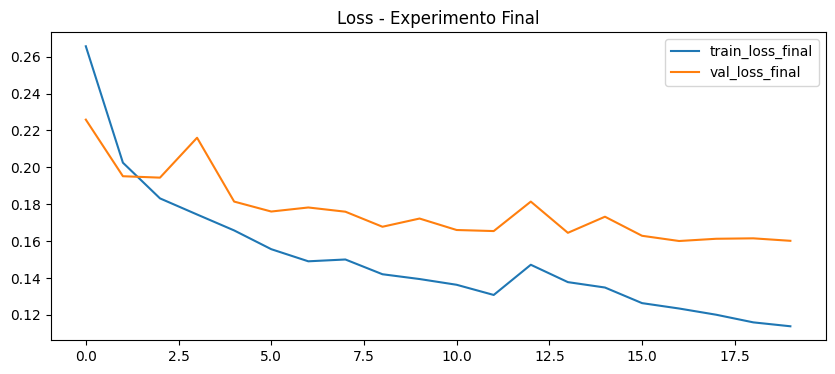

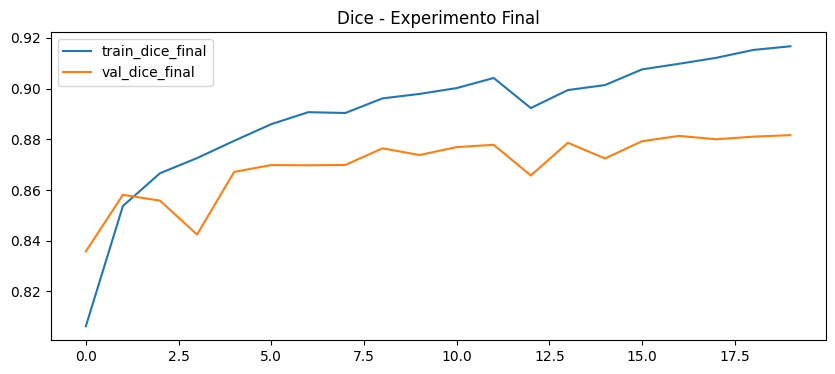

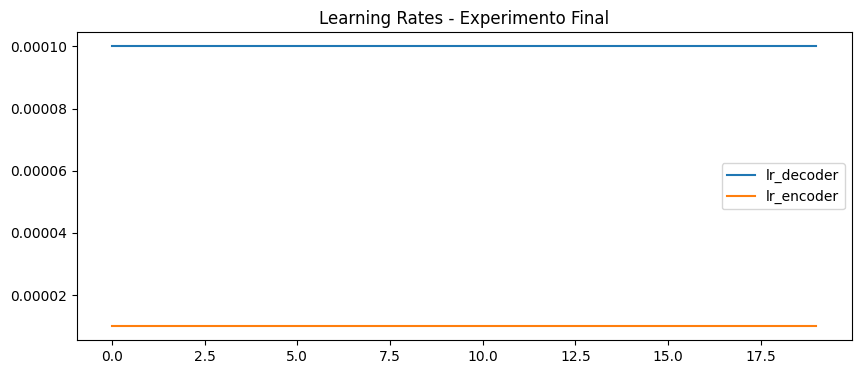

In [16]:
# ==========================================
# EXPERIMENTO FINAL - CURVAS
# ==========================================

plt.figure(figsize=(10, 4))
plt.plot(history_final["train_loss"], label="train_loss_final")
plt.plot(history_final["val_loss"], label="val_loss_final")
plt.legend()
plt.title("Loss - Experimento Final")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_final["train_dice"], label="train_dice_final")
plt.plot(history_final["val_dice"], label="val_dice_final")
plt.legend()
plt.title("Dice - Experimento Final")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_final["lr_decoder"], label="lr_decoder")
plt.plot(history_final["lr_encoder"], label="lr_encoder")
plt.legend()
plt.title("Learning Rates - Experimento Final")
plt.show()


In [ ]:
# ==========================================
# EXPERIMENTO 3 - EVALUACIÓN EN TEST
# ==========================================

@torch.no_grad()
def evaluate_loader_exp3(model, loader, device):
    model.eval()
    results = []

    for batch in tqdm(loader, desc="EXP3 Test", leave=True):
        pred_logits, gt_masks, _ = forward_medsam_batch_exp3(model, batch, device)

        probs = torch.sigmoid(pred_logits)
        preds = (probs > 0.5).float()

        for i, sample in enumerate(batch):
            pred = preds[i, 0].cpu().numpy().astype(np.uint8)
            gt = gt_masks[i, 0].cpu().numpy().astype(np.uint8)

            pred = postprocess_mask(pred)

            d = dice_np(pred, gt)
            j = iou_np(pred, gt)
            p = precision_np(pred, gt)
            r = recall_np(pred, gt)

            results.append({
                "id": sample["id"],
                "dice": d,
                "iou": j,
                "precision": p,
                "recall": r
            })

    return pd.DataFrame(results)

medsam.load_state_dict(torch.load(best_model_path_exp3, map_location=device))

df_test_results_exp3 = evaluate_loader_exp3(medsam, test_loader, device)
display(df_test_results_exp3)

print("\nResumen en TEST - Experimento 3")
print(f"Dice promedio      : {df_test_results_exp3['dice'].mean():.3f}")
print(f"IoU promedio       : {df_test_results_exp3['iou'].mean():.3f}")
print(f"Precision promedio : {df_test_results_exp3['precision'].mean():.3f}")
print(f"Recall promedio    : {df_test_results_exp3['recall'].mean():.3f}")

with mlflow.start_run(run_name="exp3_box_points_ideal", nested=True):
    mlflow.log_metrics({
        "test_dice":      df_test_results_exp3["dice"].mean(),
        "test_iou":       df_test_results_exp3["iou"].mean(),
        "test_precision": df_test_results_exp3["precision"].mean(),
        "test_recall":    df_test_results_exp3["recall"].mean(),
    })


In [17]:
# ==========================================
# EXPERIMENTO FINAL - TEST
# ==========================================

medsam.load_state_dict(torch.load(best_model_path_final, map_location=device))

df_test_results_final = evaluate_loader_exp3(medsam, test_loader, device)
display(df_test_results_final)

print("\nResumen en TEST - Experimento Final")
print(f"Dice promedio      : {df_test_results_final['dice'].mean():.3f}")
print(f"IoU promedio       : {df_test_results_final['iou'].mean():.3f}")
print(f"Precision promedio : {df_test_results_final['precision'].mean():.3f}")
print(f"Recall promedio    : {df_test_results_final['recall'].mean():.3f}")


NameError: name 'evaluate_loader_exp3' is not defined